In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
import os

print("ADAPTER:", os.path.exists("/content/drive/MyDrive/adapters"))
print("MERGED:", os.path.exists("/content/drive/MyDrive/merged_model"))
print("INT4:", os.path.exists("/content/drive/MyDrive/quantized/model-int4"))
print("INT8:", os.path.exists("/content/drive/MyDrive/quantized/model-int8"))
print("GGUF:", os.path.exists("/content/drive/MyDrive/quantized/model-q4.gguf"))

ADAPTER: True
MERGED: True
INT4: True
INT8: True
GGUF: True


In [50]:
# ─── CELL 1: GPU Check ─────────────────────────────────────────
# Sabse pehle confirm karo ki GPU mila hai
# Bina GPU ke FP16/INT4 models load nahi honge

import torch

print('='*55)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU found: {gpu_name}')
    print(f'VRAM total: {vram_total:.1f} GB')
    print(f'CUDA version: {torch.version.cuda}')
else:
    print(' No GPU')
    print('   Go to: Runtime > Change runtime type > T4 GPU')
    print('   Note: CPU pe sirf GGUF test hoga')
print('='*55)

GPU found: Tesla T4
VRAM total: 15.6 GB
CUDA version: 12.8


In [51]:
# ─── CELL 2: Install packages ──────────────────────────────────
# Wahi packages jo Day 2 aur 3 mein the

!pip install transformers peft bitsandbytes accelerate matplotlib -q
print(' Packages installed!')

 Packages installed!


In [52]:
# ─── CELL 3: Paths configure karo ──────────────────────────────
# Ye sabse important cell hai — yahan batao ki tumhare files kahan hain
#
# 3 cases hain:
# Case A: Day 2 + Day 3 done, Drive mein save kiya → sab teen models chalenge
# Case B: Sirf Day 2 done → base + fine-tuned chalega
# Case C: Kuch nahi — sirf base model benchmark hoga (ye bhi valid hai!)

import os

BASE_MODEL = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

# ─── APNE PATHS YAHAN LIKHO ───────────────────────────────────
# Agar Day 2 adapter Google Drive mein save kiya tha:
ADAPTER_PATH = '/content/drive/MyDrive/adapters'   # Example: '/content/drive/MyDrive/Week8/adapters'

# Agar Day 3 GGUF Google Drive mein save kiya tha:
GGUF_PATH = '/content/drive/MyDrive/quantized/model-q4.gguf'     # Example: '/content/drive/MyDrive/Week8/Day3/quantized/model.gguf'
# ──────────────────────────────────────────────────────────────

OUTPUT_DIR = '/content/benchmarks'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Kya available hai check karo
print('CONFIGURATION:')
print(f'  Base model:   {BASE_MODEL} Done')
print(f'  Adapter:      {ADAPTER_PATH} {"Done" if ADAPTER_PATH and os.path.exists(ADAPTER_PATH) else "(not found — base model only)"}')
print(f'  GGUF:         {GGUF_PATH} {"Done" if GGUF_PATH and os.path.exists(GGUF_PATH) else "(not found — CPU test skipped)"}')
print(f'  Output dir:   {OUTPUT_DIR} Done')

CONFIGURATION:
  Base model:   TinyLlama/TinyLlama-1.1B-Chat-v1.0 Done
  Adapter:      /content/drive/MyDrive/adapters Done
  GGUF:         /content/drive/MyDrive/quantized/model-q4.gguf Done
  Output dir:   /content/benchmarks Done


In [53]:
# ─── CELL 4: (Optional) Google Drive mount ─────────────────────
# Agar adapter ya GGUF Drive mein hai toh ye cell chalao
# Nahi hai toh skip karo

MOUNT_DRIVE = False   # True karo agar Drive se files load karni hain

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted!')

    # Drive mount ke baad paths update karo:
    ADAPTER_PATH = '/content/drive/MyDrive/adapters'
    GGUF_PATH    = '/content/drive/MyDrive/quantized/model.gguf'

    print(f'Adapter exists: {os.path.exists(ADAPTER_PATH)}')
    print(f'GGUF exists:    {os.path.exists(GGUF_PATH) if GGUF_PATH else False}')
else:
    print('Drive not mounted — using local paths only')

Drive not mounted — using local paths only


In [54]:
# ─── CELL 5: Helper functions ──────────────────────────────────
# Ye functions baar baar use honge — ek baar define karo

import time
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

def get_vram_used_gb():
    """Abhi kitna VRAM use ho raha hai"""
    if torch.cuda.is_available():
        return round(torch.cuda.memory_allocated() / 1e9, 2)
    return 0.0

def clear_gpu():
    """VRAM free karo — model del karne ke baad chalao"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def format_prompt(instruction, input_text=''):
    """Alpaca format mein prompt banao"""
    if input_text:
        return f'### Instruction:\n{instruction}\n\n### Input:\n{input_text}\n\n### Response:\n'
    return f'### Instruction:\n{instruction}\n\n### Response:\n'

def measure_speed(model, tokenizer, prompt, n_new_tokens=60):
    """
    Tokens per second measure karo.

    Steps:
    1. Prompt tokenize karo
    2. GPU pe bhejo
    3. Time start karo
    4. Model se tokens generate karo
    5. Time stop karo
    6. Tokens / time = speed
    """
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=400)
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}

    input_len = inputs['input_ids'].shape[1]

    # Warmup run — GPU ko warm karne ke liye, timing mein count nahi
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=5,
                           pad_token_id=tokenizer.eos_token_id)

    # Actual benchmark
    if torch.cuda.is_available(): torch.cuda.synchronize()
    start = time.perf_counter()

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=n_new_tokens,
            do_sample=False,           # Greedy — reproducible results ke liye
            use_cache=True,            # KV cache ON — faster inference
            pad_token_id=tokenizer.eos_token_id,
        )

    if torch.cuda.is_available(): torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    new_tokens = output.shape[1] - input_len
    tps = new_tokens / elapsed if elapsed > 0 else 0

    # Response decode karo
    response = tokenizer.decode(output[0][input_len:], skip_special_tokens=True)

    return {
        'tokens_per_sec': round(tps, 1),
        'latency_sec':    round(elapsed, 3),
        'new_tokens':     new_tokens,
        'response':       response.strip()
    }

print(' Helper functions ready!')

# Test prompts — 3 types (QA, Reasoning, Extraction)
TEST_PROMPTS = [
    {'type': 'QA',         'instruction': 'What is compound interest?',        'input': ''},
    {'type': 'Reasoning',  'instruction': 'Should a 25-year-old invest in stocks or bonds?', 'input': 'Age: 25, moderate risk'},
    {'type': 'Extraction', 'instruction': 'Extract financial metrics.',         'input': 'Revenue $500M +15% YoY. EPS $2.20. Cash $200M.'},
]
print(f'Test prompts ready: {len(TEST_PROMPTS)} prompts (QA + Reasoning + Extraction)')

 Helper functions ready!
Test prompts ready: 3 prompts (QA + Reasoning + Extraction)


In [55]:
# ─── CELL 6: Base model load ────────────────────────────────────
# Base model = koi fine-tuning nahi, seedha HuggingFace se
# FP16 mein load karenge (half precision)

print('Loading BASE model (FP16, no fine-tuning)...')
clear_gpu()
vram_before = get_vram_used_gb()

tokenizer_base = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer_base.pad_token = tokenizer_base.eos_token

model_base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,   # FP16 — 2x smaller than FP32
    device_map='auto',           # GPU pe automatically rakho
)

vram_base = get_vram_used_gb() - vram_before
print(f' Base model loaded!')
print(f'   VRAM used: {vram_base:.2f} GB')

Loading BASE model (FP16, no fine-tuning)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

 Base model loaded!
   VRAM used: 2.20 GB


In [56]:
# ─── CELL 7: Base model benchmark ──────────────────────────────
# Teeno prompts pe test karo aur results store karo

base_results = []

print('Running benchmarks on BASE model...')
print('-'*55)

for p in TEST_PROMPTS:
    prompt_str = format_prompt(p['instruction'], p['input'])
    metrics = measure_speed(model_base, tokenizer_base, prompt_str)

    row = {
        'model':       'base',
        'type':        p['type'],
        'tokens_per_sec': metrics['tokens_per_sec'],
        'latency_sec': metrics['latency_sec'],
        'vram_gb':     vram_base,
        'response':    metrics['response'][:120]  # Preview ke liye
    }
    base_results.append(row)

    print(f"[{p['type']:10}] {metrics['tokens_per_sec']:6.1f} tok/s | "
          f"{metrics['latency_sec']:.2f}s | {metrics['new_tokens']} tokens")
    print(f"  Response: {metrics['response'][:100]}...")
    print()

avg_base_tps = sum(r['tokens_per_sec'] for r in base_results) / len(base_results)
print(f'BASE model average: {avg_base_tps:.1f} tok/s | VRAM: {vram_base:.2f} GB')

# Base model delete karo — VRAM free karna hai
del model_base
clear_gpu()
print('\nGPU memory freed for next model ')

Running benchmarks on BASE model...
-------------------------------------------------------
[QA        ]   25.5 tok/s | 2.36s | 60 tokens
  Response: Compound interest is the interest that accumulates over time, compounded daily, weekly, or monthly. ...

[Reasoning ]   14.2 tok/s | 2.53s | 36 tokens
  Response: Bonds are a better investment for a 25-year-old. Bonds offer a higher potential for growth and a low...

[Extraction]   11.3 tok/s | 5.31s | 60 tokens
  Response: Revenue: $525M +15% YoY. EPS: $2.30. Cash: $225M.

### Explanation:
We extracted the revenue, EPS, a...

BASE model average: 17.0 tok/s | VRAM: 2.20 GB

GPU memory freed for next model 


In [57]:
# ─── CELL 8: Fine-tuned model load ─────────────────────────────
# Day 2 ka LoRA adapter base model ke upar load karo
# Agar adapter nahi mila → base model ke results copy karo (skip)

fine_tuned_results = []

if ADAPTER_PATH and os.path.exists(ADAPTER_PATH):
    print(f'Loading FINE-TUNED model (QLoRA adapter from {ADAPTER_PATH})...')
    clear_gpu()
    vram_before = get_vram_used_gb()

    # 4-bit mein load karo (same as Day 2 training)
    bnb_4bit = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.float16,
    )

    tokenizer_ft = AutoTokenizer.from_pretrained(BASE_MODEL)
    tokenizer_ft.pad_token = tokenizer_ft.eos_token

    model_ft = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        quantization_config=bnb_4bit,
        device_map='auto',
    )

    # LoRA adapter load karo upar se
    from peft import PeftModel
    model_ft = PeftModel.from_pretrained(model_ft, ADAPTER_PATH)

    vram_ft = get_vram_used_gb() - vram_before
    print(f'Fine-tuned model loaded!')
    print(f'   VRAM used: {vram_ft:.2f} GB')
    FT_AVAILABLE = True

else:
    print(' Adapter not found at:', ADAPTER_PATH)
    print('   SKIPPING fine-tuned benchmark')
    print('   (Set ADAPTER_PATH in Cell 3, or mount Drive in Cell 4)')
    vram_ft = 0
    FT_AVAILABLE = False

Loading FINE-TUNED model (QLoRA adapter from /content/drive/MyDrive/adapters)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Fine-tuned model loaded!
   VRAM used: 0.83 GB


In [58]:
# ─── CELL 9: Fine-tuned model benchmark ────────────────────────

if FT_AVAILABLE:
    print('Running benchmarks on FINE-TUNED model...')
    print('-'*55)

    for p in TEST_PROMPTS:
        prompt_str = format_prompt(p['instruction'], p['input'])
        metrics = measure_speed(model_ft, tokenizer_ft, prompt_str)

        row = {
            'model':          'fine_tuned',
            'type':           p['type'],
            'tokens_per_sec': metrics['tokens_per_sec'],
            'latency_sec':    metrics['latency_sec'],
            'vram_gb':        vram_ft,
            'response':       metrics['response'][:120]
        }
        fine_tuned_results.append(row)

        print(f"[{p['type']:10}] {metrics['tokens_per_sec']:6.1f} tok/s | "
              f"{metrics['latency_sec']:.2f}s | {metrics['new_tokens']} tokens")
        print(f"  Response: {metrics['response'][:100]}...")
        print()

    avg_ft_tps = sum(r['tokens_per_sec'] for r in fine_tuned_results) / len(fine_tuned_results)
    print(f'FINE-TUNED average: {avg_ft_tps:.1f} tok/s | VRAM: {vram_ft:.2f} GB')

    del model_ft
    clear_gpu()
    print('\nGPU memory freed ')
else:
    print('Fine-tuned benchmark skipped (no adapter found)')

Running benchmarks on FINE-TUNED model...
-------------------------------------------------------
[QA        ]    7.0 tok/s | 4.85s | 34 tokens
  Response: Compound interest is a financial interest rate that is calculated based on the principal and interes...

[Reasoning ]    8.2 tok/s | 2.55s | 21 tokens
  Response: Stocks are better option for age 25 as it offers higher returns with lesser risk....

[Extraction]    8.7 tok/s | 4.00s | 35 tokens
  Response: Revenue: $540M, Growth 1.9%, EPS: $2.25, Cash: $224M...

FINE-TUNED average: 8.0 tok/s | VRAM: 0.83 GB

GPU memory freed 


In [59]:
# ─── CELL 10: 4-bit Quantised model load ───────────────────────
# Ye base model ko 4-bit mein load karta hai
# Fine-tuned se farak: adapter nahi hai, sirf quantization hai

print('Loading QUANTISED model (4-bit NF4, no adapter)...')
clear_gpu()
vram_before = get_vram_used_gb()

bnb_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer_q4 = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer_q4.pad_token = tokenizer_q4.eos_token

model_q4 = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_4bit,
    device_map='auto',
)

vram_q4 = get_vram_used_gb() - vram_before
print(f'4-bit model loaded!')
print(f'   VRAM used: {vram_q4:.2f} GB')

Loading QUANTISED model (4-bit NF4, no adapter)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

4-bit model loaded!
   VRAM used: 0.77 GB


In [60]:
# ─── CELL 11: Quantised model benchmark ────────────────────────

quant_results = []

print('Running benchmarks on QUANTISED (4-bit) model...')
print('-'*55)

for p in TEST_PROMPTS:
    prompt_str = format_prompt(p['instruction'], p['input'])
    metrics = measure_speed(model_q4, tokenizer_q4, prompt_str)

    row = {
        'model':          'quantised_4bit',
        'type':           p['type'],
        'tokens_per_sec': metrics['tokens_per_sec'],
        'latency_sec':    metrics['latency_sec'],
        'vram_gb':        vram_q4,
        'response':       metrics['response'][:120]
    }
    quant_results.append(row)

    print(f"[{p['type']:10}] {metrics['tokens_per_sec']:6.1f} tok/s | "
          f"{metrics['latency_sec']:.2f}s | {metrics['new_tokens']} tokens")
    print(f"  Response: {metrics['response'][:100]}...")
    print()

avg_q4_tps = sum(r['tokens_per_sec'] for r in quant_results) / len(quant_results)
print(f'QUANTISED average: {avg_q4_tps:.1f} tok/s | VRAM: {vram_q4:.2f} GB')

del model_q4
clear_gpu()
print('\nGPU memory freed')

Running benchmarks on QUANTISED (4-bit) model...
-------------------------------------------------------
[QA        ]   16.2 tok/s | 3.71s | 60 tokens
  Response: Compound interest is the interest earned on an investment over time. It is calculated by multiplying...

[Reasoning ]   16.3 tok/s | 1.48s | 24 tokens
  Response: Bonds are a better investment for a 25-year-old with moderate risk tolerance....

[Extraction]   16.4 tok/s | 3.65s | 60 tokens
  Response: - Revenue: $500M
- EPS: $2.20
- Cash: $200M

### ### Instruction:
Calculate the ROA for the given fi...

QUANTISED average: 16.3 tok/s | VRAM: 0.77 GB

GPU memory freed


In [61]:
# ─── CELL 12: Streaming demo ────────────────────────────────────
# TextStreamer har generated token ko turant print karta hai
# User ko wait nahi karna padta full response ke liye

from transformers import TextStreamer

print('Loading model for streaming demo...')
tokenizer_s = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer_s.pad_token = tokenizer_s.eos_token

model_stream = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map='auto',
)

# Streaming prompt
prompt = format_prompt('Explain compound interest with a simple example.')
inputs = tokenizer_s(prompt, return_tensors='pt').to('cuda')

# TextStreamer = callback jo har token pe print karta hai
streamer = TextStreamer(
    tokenizer_s,
    skip_prompt=True,        # Prompt dobara print mat karo
    skip_special_tokens=True # <eos> jaisi special tokens mat dikhao
)

print('\n--- STREAMING OUTPUT (watch tokens appear one by one) ---')
with torch.no_grad():
    model_stream.generate(
        **inputs,
        max_new_tokens=120,
        streamer=streamer,       # Yahan streamer pass kiya
        do_sample=True,
        temperature=0.7,
        pad_token_id=tokenizer_s.eos_token_id,
    )
print('\n--- STREAMING COMPLETE ---')

del model_stream
clear_gpu()

Loading model for streaming demo...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- STREAMING OUTPUT (watch tokens appear one by one) ---
I am not able to create videos, but I can provide you with an example of how compound interest works.

let's say you deposit $1000 into an account that pays $10 per monthly instalment. Assuming that the interest rate is 5%, the account would have earned a total of $500 in interest.

now let's say you deposit another $1000 into the account. The interest earned from the first deposit is now compounded on a monthly basis. Let's say the interest rate

--- STREAMING COMPLETE ---


In [62]:
# ─── CELL 13: Batch inference demo ─────────────────────────────
# Batch = multiple prompts ek saath GPU pe process karo
# Kyu useful? API server mein multiple users same time pe request karte hain

print('Loading model for batch inference demo...')
tokenizer_b = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer_b.pad_token = tokenizer_b.eos_token
tokenizer_b.padding_side = 'left'  # Batch inference ke liye left padding zaroori hai

model_batch = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map='auto',
)

# 3 prompts ek saath
batch_prompts = [
    format_prompt('What is compound interest?'),
    format_prompt('Define P/E ratio.'),
    format_prompt('What is dollar-cost averaging?'),
]

# Tokenize with padding — sabko same length karo
inputs = tokenizer_b(
    batch_prompts,
    return_tensors='pt',
    padding=True,       # Chhote prompts ko pad karo longer ke barabar
    truncation=True,
    max_length=256,
)
inputs = {k: v.cuda() for k, v in inputs.items()}

# One by one timing
start_seq = time.perf_counter()
for p in batch_prompts:
    inp = tokenizer_b(p, return_tensors='pt').to('cuda')
    with torch.no_grad():
        _ = model_batch.generate(**inp, max_new_tokens=50,
                                  pad_token_id=tokenizer_b.eos_token_id)
seq_time = time.perf_counter() - start_seq

# Batch timing
if torch.cuda.is_available(): torch.cuda.synchronize()
start_batch = time.perf_counter()
with torch.no_grad():
    outputs = model_batch.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False,
        pad_token_id=tokenizer_b.eos_token_id,
    )
if torch.cuda.is_available(): torch.cuda.synchronize()
batch_time = time.perf_counter() - start_batch

print(f'\nBATCH INFERENCE RESULTS ({len(batch_prompts)} prompts):')
print(f'  One by one:  {seq_time:.2f}s total | {seq_time/3:.2f}s per prompt')
print(f'  Batch:       {batch_time:.2f}s total | {batch_time/3:.2f}s per prompt')
print(f'  Speedup:     {seq_time/batch_time:.1f}x faster with batching!')

print('\nBatch outputs:')
for i, out in enumerate(outputs):
    inp_len = inputs['input_ids'].shape[1]
    resp = tokenizer_b.decode(out[inp_len:], skip_special_tokens=True)
    print(f'  Q{i+1}: {resp[:80]}...')

del model_batch
clear_gpu()

Loading model for batch inference demo...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


BATCH INFERENCE RESULTS (3 prompts):
  One by one:  5.30s total | 1.77s per prompt
  Batch:       1.69s total | 0.56s per prompt
  Speedup:     3.1x faster with batching!

Batch outputs:
  Q1: Compound interest is the interest that accumulates over time, compounded daily, ...
  Q2: P/E ratio is the ratio of a company's earnings per share to its price-to-earning...
  Q3: Dollar-cost averaging is a strategy where investors buy and sell shares at the s...


In [63]:
import os
print(os.path.exists('/content/drive/MyDrive/quantized/model-q4.gguf'))

True


In [64]:
# ─── CELL 14: GGUF CPU test ─────────────────────────────────────
# llama-cpp-python install karo
# Ye GGUF files ko Python se run karne deta hai

!pip install llama-cpp-python --prefer-binary -q
print('llama-cpp-python installed!')

llama-cpp-python installed!


In [65]:
# ─── CELL 15: GGUF inference ────────────────────────────────────

gguf_tps = None

if GGUF_PATH and os.path.exists(GGUF_PATH):
    try:
        from llama_cpp import Llama

        print(f'Loading GGUF from: {GGUF_PATH}')
        print('Running on CPU — no GPU used!')

        llm = Llama(
            model_path=GGUF_PATH,
            n_ctx=512,
            n_threads=4,
            verbose=False,
        )

        # Test all 3 prompt types
        gguf_results_list = []
        print('\nRunning GGUF benchmarks (CPU)...')
        print('-'*55)

        for p in TEST_PROMPTS:
            prompt_str = format_prompt(p['instruction'], p['input'])
            start = time.perf_counter()
            output = llm(prompt_str, max_tokens=60, temperature=0.0, stop=['###'])
            elapsed = time.perf_counter() - start

            n_tok = output['usage']['completion_tokens']
            tps = round(n_tok / elapsed, 1)
            resp = output['choices'][0]['text'].strip()

            gguf_results_list.append({
                'model': 'gguf_cpu', 'type': p['type'],
                'tokens_per_sec': tps, 'latency_sec': round(elapsed, 3),
                'vram_gb': 0.0, 'response': resp[:120]
            })

            print(f"[{p['type']:10}] {tps:6.1f} tok/s (CPU) | {elapsed:.2f}s")
            print(f"  Response: {resp[:100]}...")
            print()

        gguf_tps = sum(r['tokens_per_sec'] for r in gguf_results_list) / len(gguf_results_list)
        print(f'GGUF CPU average: {gguf_tps:.1f} tok/s | VRAM: 0 GB (pure CPU!)')

    except Exception as e:
        print(f'GGUF test error: {e}')
        gguf_results_list = []
else:
    print('GGUF file not found — skipping CPU test')
    print('Set GGUF_PATH in Cell 3 to enable this test')
    gguf_results_list = []

Loading GGUF from: /content/drive/MyDrive/quantized/model-q4.gguf
Running on CPU — no GPU used!


llama_context: n_ctx_seq (512) < n_ctx_train (2048) -- the full capacity of the model will not be utilized



Running GGUF benchmarks (CPU)...
-------------------------------------------------------
[QA        ]    3.0 tok/s (CPU) | 5.67s
  Response: Compound interest is a mathematical concept that calculates interest on an amount over time....

[Reasoning ]    2.2 tok/s (CPU) | 3.13s
  Response: Answer: Invest in stocks...

[Extraction]    4.1 tok/s (CPU) | 8.09s
  Response: Revenue: 576.2M, Growth: 18.2%, EPS: $2.37...

GGUF CPU average: 3.1 tok/s | VRAM: 0 GB (pure CPU!)


In [66]:
# ─── CELL 16: results.csv save karo ────────────────────────────
# Sab results ek CSV mein

import csv

all_results = base_results + fine_tuned_results + quant_results
if 'gguf_results_list' in dir() and gguf_results_list:
    all_results += gguf_results_list

csv_path = f'{OUTPUT_DIR}/results.csv'
if all_results:
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=all_results[0].keys())
        writer.writeheader()
        writer.writerows(all_results)
    print(f'results.csv saved: {csv_path}')
    print(f'   Total rows: {len(all_results)}')

# Print summary table
print('\n' + '-'*65)
print('BENCHMARK SUMMARY')
print('-'*65)
print(f'{"Model":<18} {"Type":<12} {"tok/s":<10} {"Latency":<10} VRAM')
print('-'*65)
for r in all_results:
    print(f"{r['model']:<18} {r['type']:<12} {r['tokens_per_sec']:<10} "
          f"{r['latency_sec']:<10} {r['vram_gb']} GB")
print('='*65)

results.csv saved: /content/benchmarks/results.csv
   Total rows: 12

-----------------------------------------------------------------
BENCHMARK SUMMARY
-----------------------------------------------------------------
Model              Type         tok/s      Latency    VRAM
-----------------------------------------------------------------
base               QA           25.5       2.357      2.2 GB
base               Reasoning    14.2       2.531      2.2 GB
base               Extraction   11.3       5.314      2.2 GB
fine_tuned         QA           7.0        4.849      0.83 GB
fine_tuned         Reasoning    8.2        2.551      0.83 GB
fine_tuned         Extraction   8.7        4.002      0.83 GB
quantised_4bit     QA           16.2       3.705      0.77 GB
quantised_4bit     Reasoning    16.3       1.475      0.77 GB
quantised_4bit     Extraction   16.4       3.648      0.77 GB
gguf_cpu           QA           3.0        5.666      0.0 GB
gguf_cpu           Reasoning    2.2    

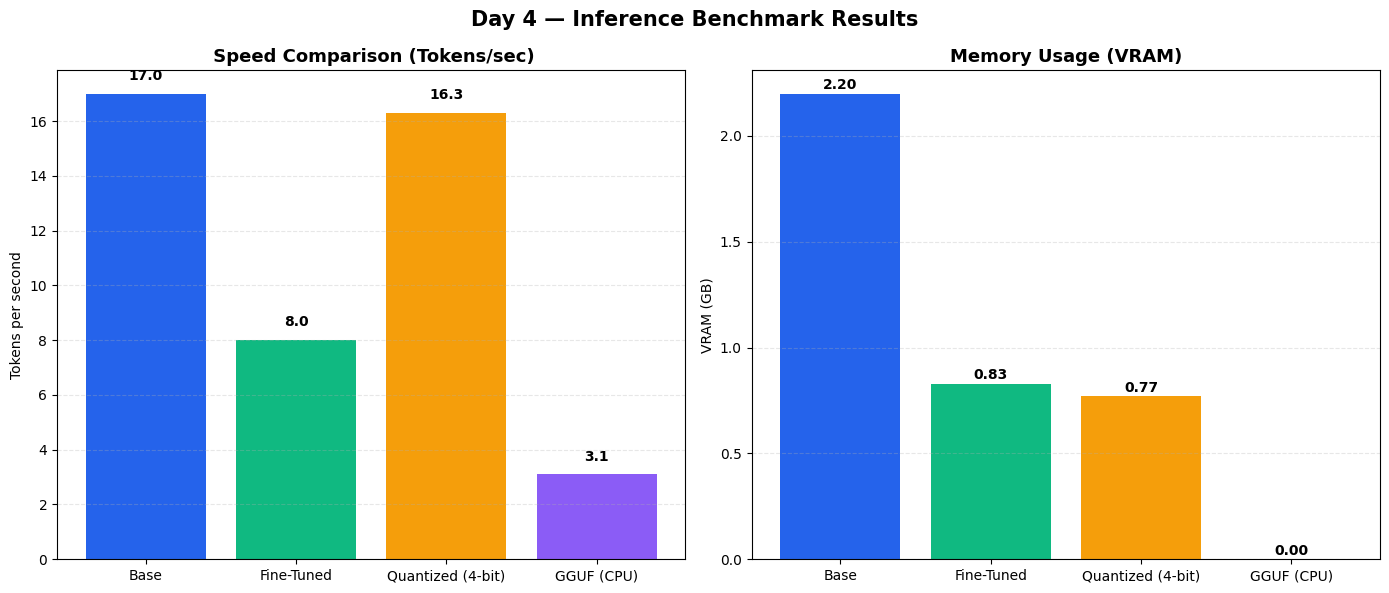

Graph saved: /content/benchmarks/benchmark_comparison.png


In [71]:
# ─── CELL 17: Improved Comparison graphs ─────────────────────────

import matplotlib.pyplot as plt

# Average per model
model_names, avg_tps, avg_vram = [], [], []

groups = {
    'Base':            base_results,
    'Fine-Tuned':      fine_tuned_results,
    'Quantized (4-bit)': quant_results,
}

if 'gguf_results_list' in dir() and gguf_results_list:
    groups['GGUF (CPU)'] = gguf_results_list

for name, rows in groups.items():
    if rows:
        model_names.append(name)
        avg_tps.append(round(sum(r['tokens_per_sec'] for r in rows) / len(rows), 1))
        avg_vram.append(rows[0]['vram_gb'])

# Better color palette (modern)
colors = ['#2563EB', '#10B981', '#F59E0B', '#8B5CF6']

plt.figure(figsize=(14, 6))

# ─── SPEED GRAPH ─────────────────────
plt.subplot(1, 2, 1)
bars1 = plt.bar(model_names, avg_tps, color=colors[:len(model_names)])

plt.title(' Speed Comparison (Tokens/sec)', fontsize=13, fontweight='bold')
plt.ylabel('Tokens per second')
plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5,
             f'{yval}', ha='center', fontsize=10, fontweight='bold')

# ─── VRAM GRAPH ─────────────────────
plt.subplot(1, 2, 2)
bars2 = plt.bar(model_names, avg_vram, color=colors[:len(model_names)])

plt.title('Memory Usage (VRAM)', fontsize=13, fontweight='bold')
plt.ylabel('VRAM (GB)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f'{yval:.2f}', ha='center', fontsize=10, fontweight='bold')

# Layout
plt.suptitle('Day 4 — Inference Benchmark Results', fontsize=15, fontweight='bold')
plt.tight_layout()

# Save
graph_path = f'{OUTPUT_DIR}/benchmark_comparison.png'
plt.savefig(graph_path, dpi=150, bbox_inches='tight')

plt.show()
print(f'Graph saved: {graph_path}')

In [72]:
# ─── CELL 18: Google Drive mein save karo ──────────────────────

SAVE_TO_DRIVE = True  # True karo!

if SAVE_TO_DRIVE:
    import shutil
    drive_dest = '/content/drive/MyDrive/Week8-colab/Day4'
    os.makedirs(drive_dest, exist_ok=True)
    shutil.copy(csv_path, drive_dest)
    shutil.copy(graph_path, drive_dest)
    print(f'Files saved to Drive: {drive_dest}')
else:
    print('Tip: SAVE_TO_DRIVE = True karo taaki results Drive mein save hon!')

Files saved to Drive: /content/drive/MyDrive/Week8-colab/Day4
